<class 'pandas.DataFrame'>
特征形状X.shape:(7043, 32)
目标形状Y.shape:(7043,)
流失比例为:26.54%
------ 1.训练集+测试集 ------
训练集大小(5634, 32)
测试集大小(1409, 32)
训练集流失比例:0.2653532126375577
测试集流失比例:0.2654364797728886
预测流失人数:293
预测平均流失概率：0.27122418804285375
准确率:0.7949(79.49%)
AUC:0.8239

分类报告：
              precision    recall  f1-score   support

         未流失       0.83      0.90      0.87      1035
          流失       0.65      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409


混淆矩阵:
[[931 104]
 [185 189]]


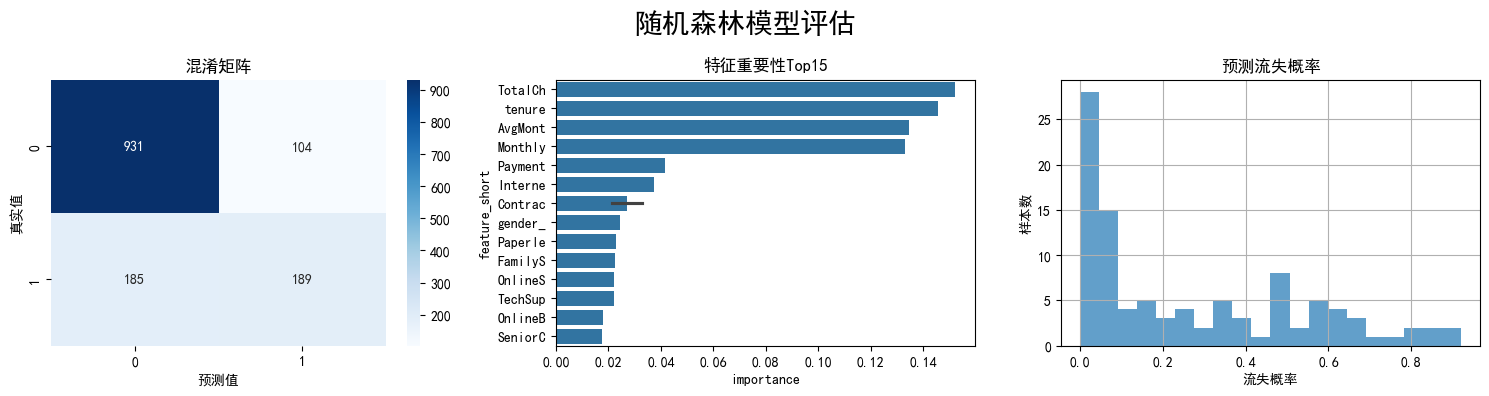

随机森林的准确率ACC: 0.7949, AUC:0.8239
XGBoost的准确率ACC: 0.8013, AUC:0.8392

XGBoost的分类报告：
              precision    recall  f1-score   support

         未流失       0.84      0.90      0.87      1035
          流失       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



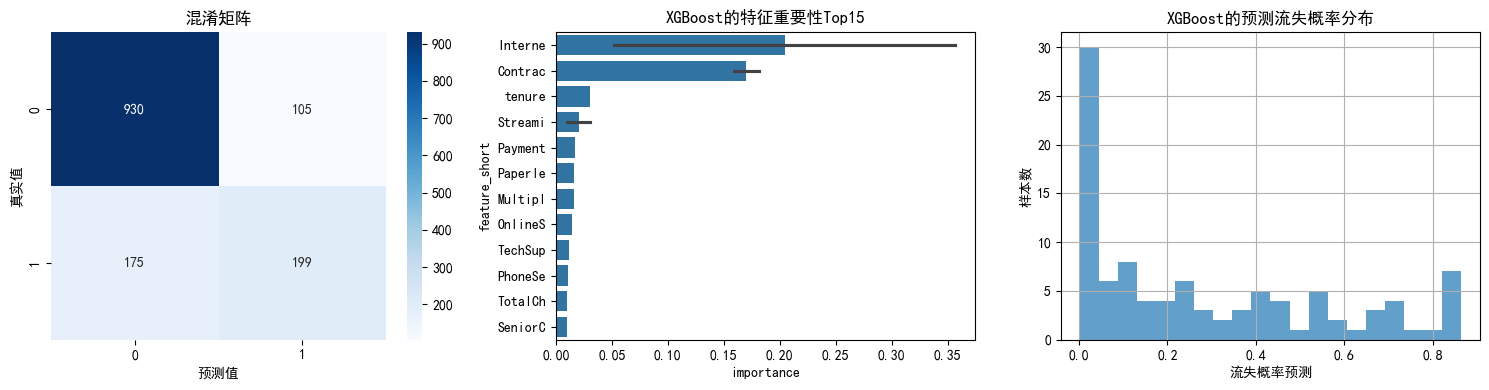

=========== 方法一：只改proba判定门槛，不训练模型 ===============
最佳判定门槛threshold为：0.29
原 recall:0.532
新 recall:0.778
原 precision:0.655
新 precision:0.526
原 f1_score:0.5870206489675516
新 f1_score:0.627831715210356
====== 方法二：不改判定门槛，只调整模型内部权重，告诉XGBoost流失类比未流失类重要 ====
最优scale:2.5
加权前 recall: 0.532
加权后 recall: 0.781
加权前 precision: 0.655
加权后 precision: 0.538
加权前 f1_score:0.5870206489675516
加权后 f1_score:0.6368593238822247
====== 方法三：结合方法一 + 方法二 =========
结合两者时的，相对最优判断门槛threshold:0.48
结合前 recall: 0.532
结合后 recall: 0.789
结合前 precision: 0.655
结合后 precision: 0.535
结合前 f1_score:0.5870206489675516
结合后 f1_score:0.6378378378378379
======= 总结 =======
优化前的的AUC:0.8391795189749155
综合最优的AUC:0.8406507530548453

综合最优的分类报告：
              precision    recall  f1-score   support

         未流失       0.91      0.75      0.82      1035
          流失       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.7

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report,\
                            confusion_matrix, roc_auc_score
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import joblib

# #设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

X = pd.read_csv('../data/X_processed.csv')
Y = pd.read_csv('../data/Y_processed.csv')
print(type(Y)) # ---> Y为DataFrame格式，需要转为Series

if isinstance(Y, pd.DataFrame):
    Y = Y.iloc[:,0]
print(f"特征形状X.shape:{X.shape}")
print(f"目标形状Y.shape:{Y.shape}")
print(f"流失比例为:{Y.mean():.2%}")

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify = Y
)
print('------ 1.训练集+测试集 ------')
print(f"训练集大小{X_train.shape}")
print(f"测试集大小{X_test.shape}")
print(f"训练集流失比例:{Y_train.mean()}")
print(f"测试集流失比例:{Y_test.mean()}")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
Y_pred = rf.predict(X_test)
Y_pred_proba = rf.predict_proba(X_test)[:, 1]
print(f"预测流失人数:{Y_pred.sum()}")
print(f"预测平均流失概率：{Y_pred_proba.mean()}")

#准确率
acc = accuracy_score(Y_test, Y_pred)
print(f"准确率:{acc:.4f}({acc:.2%})")

#AUC
auc = roc_auc_score(Y_test, Y_pred_proba)
print(f"AUC:{auc:.4f}")

#详细报告
print("\n分类报告：")
print(classification_report(Y_test, Y_pred, target_names=['未流失','流失']))

#混淆矩阵
cm = confusion_matrix(Y_test, Y_pred)
print("\n混淆矩阵:")
print(cm)

# #可视化，包含三张图
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('随机森林模型评估', fontsize=20)

    #图一，混淆矩阵
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('预测值')
axes[0].set_ylabel('真实值')
axes[0].set_title('混淆矩阵')

    #图二，特征重要性
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)
importance['feature_short'] = importance['feature'].str.slice(0,7)
sns.barplot(x='importance', y='feature_short', data=importance, ax=axes[1])
axes[1].set_title('特征重要性Top15')

    #图三，流失概率分布（对比真实目标）
    #取前100个测试样本
test_df = pd.DataFrame({
    '真实标签': Y_test.values[:100],
    '预测概率': Y_pred_proba[:100]
})
test_df['预测概率'].hist(bins=20, alpha=0.7, label='预测概率', ax=axes[2])
axes[2].set_title('预测流失概率')
axes[2].set_xlabel('流失概率')
axes[2].set_ylabel('样本数')

plt.tight_layout()
plt.savefig('../Output/day4_rfModel_evaluation.png', dpi=150)
plt.show()

#======================== XGBoost模型 ======================
xgb_model = xgb.XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 42,
    eval_metric = 'logloss'
)

xgb_model.fit(X_train, Y_train)
Y_pred_xgb = xgb_model.predict(X_test)
Y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

acc_xgb = accuracy_score(Y_test, Y_pred_xgb)
auc_xgb = roc_auc_score(Y_test, Y_pred_proba_xgb)

print(f"随机森林的准确率ACC: {acc:.4f}, AUC:{auc:.4f}")
print(f"XGBoost的准确率ACC: {acc_xgb:.4f}, AUC:{auc_xgb:.4f}")
print("\nXGBoost的分类报告：")
print(classification_report(Y_test,Y_pred_xgb, target_names=['未流失', '流失']))

# #====================XGBoost的三张图片====================
fig, axes = plt.subplots(1,3, figsize=(15,4))

# #图一：混淆矩阵
cm_xgb = confusion_matrix(Y_test,Y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('预测值')
axes[0].set_ylabel('真实值')
axes[0].set_title('混淆矩阵')

# #图二：特征重要性
importance_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)
importance_xgb['feature_short'] = importance_xgb['feature'].str.slice(0,7)
sns.barplot(x='importance', y='feature_short', data=importance_xgb, ax=axes[1])
axes[1].set_title('XGBoost的特征重要性Top15')

# #图三：流失概率分布(对比真实目标) 
#取前100个测试样本
test_df = pd.DataFrame({
    '真实标签': Y_test.values[:100],
    '预测概率': Y_pred_proba_xgb[:100]
})
test_df['预测概率'].hist(bins=20, alpha=0.7, label='预测概率', ax= axes[2])
axes[2].set_title('XGBoost的预测流失概率分布')
axes[2].set_xlabel('流失概率预测')
axes[2].set_ylabel('样本数')

plt.tight_layout()
plt.savefig('../Output/day4_xgbModel_evaluation.png', dpi=150)
plt.show()

# ======================== 尝试优化XGBoost的recall（召回率） ============================
print("=========== 方法一：只改proba判定门槛，不训练模型 ===============")
fscore = f1_score(Y_test, Y_pred_xgb)
for i in range(20, 51):
    temp_threshold = i / 100
    Y_pred_xgb_new = (Y_pred_proba_xgb >= temp_threshold).astype(int)
    score = f1_score(Y_test, Y_pred_xgb_new)
    if(score > fscore):
        fscore = score
        threshold = temp_threshold
print(f"最佳判定门槛threshold为：{threshold}")
Y_pred_xgb_new = (Y_pred_proba_xgb >= threshold).astype(int)
print(f"原 recall:{recall_score(Y_test, Y_pred_xgb):.3f}")
print(f"新 recall:{recall_score(Y_test, Y_pred_xgb_new):.3f}")
print(f"原 precision:{precision_score(Y_test, Y_pred_xgb):.3f}")
print(f"新 precision:{precision_score(Y_test, Y_pred_xgb_new):.3f}")
print(f"原 f1_score:{f1_score(Y_test, Y_pred_xgb)}")
print(f"新 f1_score:{f1_score(Y_test, Y_pred_xgb_new)}")

#提升recall
print("====== 方法二：不改判定门槛，只调整模型内部权重，告诉XGBoost流失类比未流失类重要 ====")
scale = 1; fscore = f1_score(Y_test, Y_pred_xgb)
for temp_scale in [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]:
    xgb_temp_weighted = xgb.XGBClassifier(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = 5,
        scale_pos_weight = temp_scale,
        random_state = 42,
        eval_metric = 'logloss'
    )
    xgb_temp_weighted.fit(X_train, Y_train)
    Y_pred_xgb_weighted = xgb_temp_weighted.predict(X_test)
    score = f1_score(Y_test, Y_pred_xgb_weighted)
    if(score > fscore):
        xgb_weighted = xgb_temp_weighted
        fscore = score
        scale = temp_scale
print(f"最优scale:{scale}")
Y_pred_xgb_weighted = xgb_weighted.predict(X_test)
print(f"加权前 recall: {recall_score(Y_test, Y_pred_xgb):.3f}")
print(f"加权后 recall: {recall_score(Y_test, Y_pred_xgb_weighted):.3f}")
print(f"加权前 precision: {precision_score(Y_test, Y_pred_xgb):.3f}")
print(f"加权后 precision: {precision_score(Y_test, Y_pred_xgb_weighted):.3f}")
print(f"加权前 f1_score:{f1_score(Y_test, Y_pred_xgb)}")
print(f"加权后 f1_score:{f1_score(Y_test, Y_pred_xgb_weighted)}")

print("====== 方法三：结合方法一 + 方法二 =========")
fscore = f1_score(Y_test, Y_pred_xgb)
Y_pred_proba_xgb_weighted = xgb_weighted.predict_proba(X_test)[:,1]
for i in range(20, 51):
    temp_threshold = i / 100
    Y_pred_xgb_weighted_new = (Y_pred_proba_xgb_weighted >= temp_threshold).astype(int)
    score = f1_score(Y_test, Y_pred_xgb_weighted_new)
    if(score > fscore):
        fscore = score
        threshold_new = temp_threshold
print(f"结合两者时的，相对最优判断门槛threshold:{threshold_new}")
Y_pred_xgb_weighted_new = ( Y_pred_proba_xgb_weighted > threshold_new).astype(int)
print(f"结合前 recall: {recall_score(Y_test, Y_pred_xgb):.3f}")
print(f"结合后 recall: {recall_score(Y_test, Y_pred_xgb_weighted_new):.3f}")
print(f"结合前 precision: {precision_score(Y_test, Y_pred_xgb):.3f}")
print(f"结合后 precision: {precision_score(Y_test, Y_pred_xgb_weighted_new):.3f}")
print(f"结合前 f1_score:{f1_score(Y_test, Y_pred_xgb)}")
print(f"结合后 f1_score:{f1_score(Y_test, Y_pred_xgb_weighted_new)}")
print("======= 总结 =======")
print(f"优化前的的AUC:{roc_auc_score(Y_test, Y_pred_proba_xgb)}")
print(f"综合最优的AUC:{roc_auc_score(Y_test, Y_pred_proba_xgb_weighted)}")
print("\n综合最优的分类报告：")
print(classification_report(Y_test,Y_pred_xgb_weighted_new, target_names=['未流失', '流失']))

# #--------------- 保存模型 --------------------
joblib.dump(xgb_weighted, '../models/xgb_final_model.pkl')

# #------------------ 检验有无保存成功 --------------
loaded_model = joblib.load('../models/xgb_final_model.pkl')
print(type(loaded_model))

### 模型构建
- `利用Y = Y.iloc[:,0]`可将DataFrame格式转为Series
- `从sklearn.model_selction 导入 train_test_split训练测试划分函数` stratify = Y,表示按照Y的比例进行比例分层采样，同时test_size=0.2, 测试集占原数据20%,训练集占80%,如果数据量再大，就可将训练集的比例相对减少，测试集的比例相对增加.  random_state=42,随机数种子=42.
- `从sklearn.ensemble集成学习模块里面 import导入 RandomForestClassifier随机森林分类器`去用于分类问题，随机森林是将很多棵决策树放在一起，每棵树给一个预测结果，然后投票决定
- `RandomForestClassifier()`创建模型，n_estimators数的数量，random_state随机种子
- `rf.predict(X_test) -> 返回01列表，判断是否流失 ； rf.predict_proba(X_test) 返回[[不流失概率,流失概率],,[...],[...,...]], 0-1之间的概率，用于评估可信度，画ROC曲线`
- `acc = accuracy_score(Y_test, Y_pred)` acc就是模型评估的准确性accuracy
- `auc = roc_auc_score(Y_test,Y_pred_proba)` AUC是比准确性更实诚、关键的指标，对于ACC,acc = accuracy_score(Y_test,Y_pred) 对应的Y_pred = (Y_pred_proba>=0.5).astype(int),只依赖于0.5这个阈值，而AUC是综合了Y_pred_proba，即综合了所有阈值的，衡量了模型在所有阈值下的总和排序能力，所以一般AUC更准。
- `对于classification_report()`反应的分类报告，precision为模型的精确率，recall为召回率，比如precision下的流失,对应的就是，模型预测一个人为流失，但他真正流失的概率。recall下的流失，为一个人会流失，而模型会准确分辨出他，并去挽留的概率。f1-score为上述两者的调和平均，support为真实样本数量
- `macro avg`为暴力平均，每个人都很公平，例如左边0.74 = (0.83+0.65)/2，公平但不现实，忽略样本结构; 而'weighted avg`为加权平均，真实但不公平，会淹没少数类。所以真正看效果的话，如果侧重于多数类，就看weighted，如果不想牺牲少数类，追求公平，就看macro
- `cm = confusion_matrix(Y_test, Y_pred)`混淆矩阵是模型预测结果的原始数据，precision和recall，f1就是全部来自于它
- `sns.heatmap()，Seaborn的热力图函数，cm混淆矩阵，annot=True在格子中显示数字，fmt='d'数字格式(format)为整数,cmap='Blues'蓝色系`
- `f1_score(Y_true, Y_pred)`在不指定average参数时，默认为label=1的流失类，就默认计算的是流失类的f1_score